# Exercises week 38

**FYS-STK3155/4155, fall 2026 — deadline Friday September 18 at midnight.**

## Adaptive learning rates and stochastic gradient descent

The aim this week is that you extend last week's gradient descent code with
the adaptive methods AdaGrad, RMSProp and Adam, that you understand what each
of them does to the step and why their learning rate is not the learning rate
of plain gradient descent, and that you replace the full gradient by a
minibatch gradient with epochs and a learning-rate schedule. Everything here is
reused directly in parts f) and h) of Project 1. The code developed in the
Tuesday session (`week38tuesday.ipynb`, Cases 1 and 2) is meant to be reused,
and the Monday notebook (`week38.ipynb`) contains worked examples of every
piece.

After completing these exercises you will have

* derived the bias correction of Adam and the first step of the adaptive
  methods, and shown why they are insensitive to the scale of a feature;
* your own implementation of AdaGrad, RMSProp and Adam in the same
  three-function structure as last week's gradient descent, checked against
  the closed-form solutions of OLS and Ridge;
* scanned the learning rate for each method and related the windows you find
  to $2/\lambda_{\max}$ (Section 4.5) and to what $\gamma$ means for an
  adaptive method (Sections 4.8–4.12);
* a stochastic gradient descent loop with minibatches, epochs and the
  schedule of Eq. (4.40), and studied the batch size and the schedule
  (Section 4.7);
* applied all of it to the Runge function at degree 10, the problem nothing
  converged on last week.

Reading: Chapter 4, Sections 4.7–4.13 of the book; Goodfellow et al.,
Sections 8.1–8.5.

## The data

We keep last week's function,

$$
f(x) = 2 - x + 5x^2, \qquad x \in [-2, 2],
$$

with $n = 100$ points and Gaussian noise of standard deviation $0.5$, fitted
with polynomial features of degree 2 (an easy problem, $\kappa \approx 1.3$)
and degree 5 (a hard one, $\kappa \approx 520$). As last week, standardise the
columns of the design matrix, centre $\boldsymbol{y}$ and use no intercept
column; the closed-form OLS and Ridge solutions are your reference.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def exercise_data(n=100, degree=2, noise=0.5, seed=2026):
    """Standardised polynomial design matrix (no intercept column) and centred targets."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-2.0, 2.0, n)
    y = 2.0 - x + 5.0 * x**2 + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    return X_norm, y - y.mean()

def closed_form(X, y, lam=0.0):
    """(X^T X + n lambda I)^-1 X^T y, the 1/n convention of Eq. (3.95)."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)

def cost(theta, X, y, lam=0.0):
    """Eqs. (4.12) and (4.16)."""
    return np.sum((X @ theta - y) ** 2) / len(y) + lam * theta @ theta

def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): your analytical gradient from last week (or jax.grad of cost)."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta

def hessian_eigs(X, lam=0.0):
    n = len(X)
    return np.linalg.eigvalsh((2.0 / n) * X.T @ X + 2.0 * lam * np.eye(X.shape[1]))

X2, y2 = exercise_data(degree=2)
X5, y5 = exercise_data(degree=5)
for X in (X2, X5):
    eigs = hessian_eigs(X)
    print(f"degree {X.shape[1]}: kappa = {eigs.max() / eigs.min():.1f}, 2/lambda_max = {2 / eigs.max():.3f}")

degree 2: kappa = 1.3, 2/lambda_max = 0.894
degree 5: kappa = 520.3, 2/lambda_max = 0.354


## Exercise 1: what the adaptive methods do to the step (analytical)

The three adaptive methods replace the single learning rate $\gamma$ by a
per-coordinate step $\gamma/\sqrt{v_j}$, where $v_j$ estimates the second
moment of the gradient in coordinate $j$ (Section 4.8).

### 1a)

Unroll the RMSProp recursion of Eq. (4.47),
$\boldsymbol{v}_t = \rho\,\boldsymbol{v}_{t-1} + (1-\rho)\boldsymbol{g}_t^2$ with
$\boldsymbol{v}_0 = \boldsymbol{0}$, to obtain Eq. (4.49),
$\boldsymbol{v}_t = (1-\rho)\sum_{j=1}^{t}\rho^{\,t-j}\boldsymbol{g}_j^2$, and show
that the weights sum to $1 - \rho^t$. After how many steps has a gradient's
weight fallen below $1/e$ of its initial weight, for $\rho = 0.9$ and
$\rho = 0.99$? Compare with AdaGrad's sum, Eq. (4.42), whose weights are all
one.

We use induction to arrive at Eq. (4.49). Knowing that $\boldsymbol{v}_0 = \boldsymbol{0}$, we take the base case to be

$$
\boldsymbol{v}_1 = (1 - \rho) \boldsymbol{g}_1^2 = (1 - \rho) \sum_{j = 1}^1 \rho^{1 - j} \boldsymbol{g}_j^2.
$$

Assume that Eq. (4.49) holds for some $t = k - 1 \in \mathbb{N}$. Then for $t = k$, we have

$$
\boldsymbol{v}_k = \rho\boldsymbol{v}_{k - 1} + (1 - \rho)g_k^2 = \rho (1 - \rho) \sum_{j = 1}^{k - 1} \rho^{k - 1 - j} g_j^2 + (1 - \rho)g_k^2 = (1 - \rho) \sum_{j = 1}^k \rho^{k - j} g_j^2.
$$

Thus, by induction, Eq. (4.49) holds for all $t \in \mathbb{N}$.

The gradient $\boldsymbol{g}_j$ thus enters $\boldsymbol{v}_t$ with weights $w_{t,j} = (1 - \rho) \rho^{t - j}$. Summing over $j$ yields

$$
\sum_{j = 1}^t w_{t,j} = (1 - \rho)\rho^t \sum_{j = 1}^t \rho^{-j}. 
$$

Setting $S = \sum_{j = 1}^t \rho^{-j}$, we find that

$$
S = \left(\frac{1}{\rho} + \dots + \frac{1}{\rho^t}\right) = \frac{1}{\rho}\left(1 + S - \frac{1}{\rho^t}\right).
$$

Multiplying by $\rho$ on both sides and subtracting by $S$ then yields

$$
(\rho - 1)S = 1 - \frac{1}{\rho^t} = \frac{\rho^t - 1}{\rho^t},
$$

giving

$$
S = \frac{\rho^t - 1}{(\rho - 1)\rho^t} = \frac{1 - \rho^t}{(1 - \rho)\rho^t}.
$$

Thus,

$$
\sum_{j = 1}^t w_{t,j} = (1 - \rho)\rho^t \frac{1 - \rho^t}{(1 - \rho)\rho^t} = 1 - \rho^t. 
$$

We may rewrite the expression for the sum of the weights as

$$
\sum_{j = 1}^t w_{t,j} = (1 - \rho) \sum_{j = 1}^t \rho^{t - j} = (1 - \rho) \sum_{j = 0}^{t - 1} \rho^j
$$

We take the initial weight to be $1 - \rho$ (the $j = 0$ term on the extreme right-hand side). The $j$-th term then has weight $\rho^j$ times the initial weight. This fraction falls below $e^{-1}$ when $j > -1/\ln(\rho)$. Setting $\rho = 0.9$ gives $j > 9.5$ and setting $\rho = 0.99$ gives $j > 99.5$. In other words, for $\rho = 0.9$ and $\rho = 0.99$, it takes $10$ and $100$ steps, respectively, for a gradient's weight to fall below $1/e$ of the initial weight.

Thus, in RMSProp, older terms have less weight, whereas in AdaGrad's sum, all terms have equal weight and we run into infinite memory problems. In other words, in RMSProp, depending on the desired precision, older terms may be discarded.

### 1b)

Now Adam. Assume the gradient is stationary with $\mathbb{E}[g^2]$ constant.
Take the expectation of the unrolled second moment of Eq. (4.52) and derive
Eq. (4.53), $\mathbb{E}[v_t] = (1-\beta_2^{\,t})\,\mathbb{E}[g^2]$. Do the same
for the first moment with $\beta_1$. Explain why dividing by $1-\beta_i^t$,
Eq. (4.54), removes the bias exactly, and evaluate the correction factors at
$t = 1$, $t = 10$ and $t = 1000$ for the default $\beta_1 = 0.9$,
$\beta_2 = 0.999$.

As we derived in **1a)**, we use that

$$
\sum_{j = 1}^t \rho^{-j} = \frac{1 - \rho^t}{(1 - \rho)\rho^t}.
$$

We have

$$
\mathbb{E}[v_t] = \mathbb{E}[g^2] (1 - \beta_2)\rho^t \sum_{j = 1}^t \beta_2^{-j} = \mathbb{E}[g^2] (1 - \beta_2^t) .
$$

Similarly,
$$
\mathbb{E}[m_t] = \mathbb{E}[g] (1 - \beta_1)\rho^t \sum_{j = 1}^t \beta_1^{-j} = \mathbb{E}[g] (1 - \beta_1^t).
$$

Dividing by $1 - \beta_i^t$ yields $\mathbb{E}[\hat{m}_t] = \mathbb{E}[g]$ and $\mathbb{E}[\hat{v}_t] = \mathbb{E}[g^2]$ exactly, not just asymptotically. By rescaling the momenta, you remove the bias from starting with zero initial momenta.

| Correction factors $1/(1 - \beta_i^t)$ | $t = 1$ | $t = 10$ | $t = 1000$ |
| :- | -: | -: | -: |
| $\beta_1 = 0.9$ | $10$ | $\approx 1.54$ | $\approx 1.00$ |
| $\beta_2 = 0.999$ | $1000$ | $\approx 100$ | $\approx 1.58$ |

### 1c)

Show that the first step of Adam, Eq. (4.55) at $t = 1$, is
$\Delta\theta_j = -\gamma\,\mathrm{sign}(g_{1,j})$ (up to $\epsilon$),
independent of the size of the gradient, and that the same holds for AdaGrad.
What is the first step of RMSProp, which has no bias correction, with
$\rho = 0.99$? What does this tell you about the meaning of $\gamma$ for these
methods, compared with plain gradient descent? Without bias correction, by
what factor would Adam's first step be too long?

We have that

$$
\hat{\boldsymbol{m}}_1 = \frac{\boldsymbol{m}_1}{1 - \beta_1} = \frac{1}{1 - \beta_1}(1 - \beta_1) \sum_{j = 1}^1 \beta_1^{1 - j} \boldsymbol{g}_j = \boldsymbol{g}_1
$$

and

$$
\hat{\boldsymbol{v}}_1 = \frac{\boldsymbol{v}_1}{1 - \beta_2} = \frac{1}{1 - \beta_2}(1 - \beta_2) \sum_{j = 1}^1 \beta_2^{1 - j} \boldsymbol{g}_j^2 = \boldsymbol{g}_1^2.
$$

From Eq. (4.55), we then get

$$
\Delta \theta_{1,j} = -\frac{\alpha}{\sqrt{g_{1,j}^2} + \varepsilon} g_{1,j} = -\alpha \frac{g_{1,j}}{|g_{1,j}| + \varepsilon} \xrightarrow{\varepsilon \to 0} -\alpha \operatorname{sign}(g_{1,j}).
$$

For AdaGrad, we have

$$
\Delta \theta_{1,j} = -\frac{\gamma}{\sqrt{\varepsilon + r_{1,j}}} g_{1,j} = -\gamma \frac{g_{1,j}}{\sqrt{\varepsilon + g_{1,j}^2}} \xrightarrow{\varepsilon \to 0} -\gamma \frac{g_{1,j}}{|g_{1,j}|} = -\gamma \operatorname{sign}(g_{1,j}).
$$

For RMSProp, we have that

$$
\boldsymbol{v}_1 = (1 - \rho) \boldsymbol{g}_1^2
$$

and hence,

$$
\Delta \theta_{1,j} = -\frac{\gamma}{\sqrt{v_{1,j} + \varepsilon}} g_{1,j} = -\gamma \frac{g_{1,j}}{\sqrt{(1 - \rho) g_{1,j}^2 + \varepsilon}} \xrightarrow{\varepsilon \to 0} -\frac{\gamma}{\sqrt{1 - \rho}} \frac{g_{1,j}}{|g_{1,j}|} = -\frac{\gamma}{\sqrt{1 - \rho}} \operatorname{sign}(g_{1,j}).
$$

With $\rho = 0.99$ this is

$$
\Delta \theta_{1,j} = -10\gamma \operatorname{sign}(g_{1,j}).
$$

Here, $\gamma$ represents the distance travelled. This differs from the learning rate in gradient descent, where $\gamma$ acts more like a scaling factor than a step size, which one multiplies the gradient by.

Without bias correction, we have

$$
\boldsymbol{m}_1 = (1 - \beta_1) \boldsymbol{g}_1
$$

and

$$
\boldsymbol{v}_1 = (1 - \beta_2) \boldsymbol{g}_1^2.
$$

Thus,

$$
\Delta \theta_{1,j} = -\alpha \frac{(1 - \beta_1) g_{1,j}}{\sqrt{1 - \beta_2}|g_{1,j}| + \varepsilon} \xrightarrow{\varepsilon \to 0} -\alpha \frac{(1 - \beta_1)}{\sqrt{1 - \beta_2}} \operatorname{sign}(g_{1,j}).
$$

With $\beta_1 = 0.9$ and $\beta_2 = 0.999$, this is

$$
\Delta \theta_{1,j} \approx -3.16\gamma \operatorname{sign}(g_{1,j}).
$$

In other words, the step size is too large by a factor $\approx 3.16$.

### 1d)

Multiply one feature (one column of $\boldsymbol{X}$) by a constant $c$. Show
that the corresponding component of the gradient of the OLS cost scales by
$c$ and that the AdaGrad/RMSProp/Adam step in that coordinate is unchanged,
whereas the plain gradient descent step scales by $c$ (and the stability bound
$2/\lambda_{\max}$ moves). Why does this *not* mean that standardising the
data is unnecessary for the adaptive methods? (Hint: the Tuesday session's
rotated bowl.)

We recall that the gradient of the OLS cost is

$$
\nabla_{\boldsymbol{\theta}} C(\boldsymbol{\theta})  = -\frac{2}{n} \boldsymbol{X}^T(\boldsymbol{y} - \boldsymbol{X}\boldsymbol{\theta}).
$$

In component form, this is

$$
(\nabla_{\boldsymbol{\theta}})_i = -\frac{2}{n} \sum_j X_{ji} \left(y_j - \sum_k X_{jk}\theta_k\right).
$$

Multiplying the $i$-th column of $X$ by a constant $c$ thus yields

$$
-\frac{2}{n} \sum_j cX_{ji} \left(y_j - \sum_{k \neq i} X_{jk}\theta_k - cX_{ji}\theta_i\right).
$$

Assuming

$$
c \sum_{j} X_{ji}\theta_i \ll |(\nabla_{\boldsymbol{\theta}})_i|,
$$

we see that

$$
-\frac{2}{n} \sum_j cX_{ji} \left(y_j - \sum_{k \neq i} X_{jk}\theta_k - cX_{ji}\theta_i\right) \approx c(\nabla_{\boldsymbol{\theta}})_i.
$$

As we saw in **1c)**, the AdaGrad/RMSProp/Adam step size does not depend on the magnitude of the gradient in the $i$-th coordinate, only on its sign. This differs from plain gradient descent, as the step size is directly dependent on the size of the gradient, not just its direction.

It is still not unnecessary to standardise the data for the adaptive methods because the momenta still depend on the gradient, where

## Exercise 2: implementing AdaGrad, RMSProp and Adam

Extend last week's code with one step function that holds all five
optimisers. The template below has the update rules to fill in; keep the
gradient as an argument so that the analytical gradient and `jax.grad` are
interchangeable, as in part e) of Project 1.

In [2]:
def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t = 1, 2, ...; state carries the running quantities."""
    if method == "plain":                                    # Eq. (4.10)
        return theta - gamma * g, state
    if method == "momentum":                                 # Eq. (4.28)
        state["v"] = v = beta * state.get("v", 0.0) + gamma * g  
        return theta - v, state
    if method == "adagrad":                                  # Eqs. (4.42) and (4.45)
        state["r"] = r = state.get("r", 0.0) + g * g  
        return theta - gamma * g / (np.sqrt(r) + eps), state 
    if method == "rmsprop":                                  # Eqs. (4.47) and (4.48)
        state["r"] = r =  rho * state.get("r", 0.0) + (1.0 - rho) * g * g 
        return theta - gamma * g / (np.sqrt(r) + eps), state
    if method == "adam":                                     # Eqs. (4.51), (4.52), (4.54), (4.55)
        state["m"] = m = beta1 * state.get("m", 0.0) + (1.0 - beta1) * g  
        state["r"] = r = beta2 * state.get("r", 0.0) + (1.0 - beta2) * g * g 
        m_hat, r_hat = m / (1.0 - beta1**t) , r / (1.0 - beta2**t)
        return theta - gamma * m_hat / (np.sqrt(r_hat) + eps), state
    raise ValueError(f"unknown method {method}")

def optimise(grad, theta0, method, gamma, num_iters=1000, tol=1e-8, **kw):
    """Full-gradient loop; returns all iterates and the number of steps taken."""
    theta, state = np.array(theta0, dtype=float), {}
    history = [theta.copy()]
    for t in range(1, num_iters + 1):
        g = grad(theta)
        theta, state = optimiser_step(method, theta, g, state, t, gamma, **kw)
        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(history), t

### 2a)

Run all five methods on the degree-2 data for OLS and for Ridge with
$\lambda = 0.01$ (remember the $n\lambda\boldsymbol{I}$ of the closed form).
Use $\gamma = 0.5$ for plain gradient descent and momentum and try
$\gamma \in \{0.01, 0.1\}$ for the adaptive methods. Do all of them converge to
the closed-form solution? Plot the distance
$\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\|$ against the iteration for
each method.

### 2b)

Repeat for the degree-5 data ($\kappa = 520$), with $\gamma = 0.9 \cdot 2/\lambda_{\max}$
for plain descent and momentum. Report the number of iterations to reach
$\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\| < 10^{-6}$ for each method,
and identify the method that does not get there at a constant $\gamma$.
Explain why, using your result from exercise 1c).

### 2c)

Check one method against a library implementation: for the degree-2 OLS
problem, run `optax.adam` (or `torch.optim.Adam`, or any other) with the same
$\gamma$, $\beta_1$, $\beta_2$ and $\epsilon$ from the same starting point, and
compare the first ten iterates with your own. They should agree to rounding.
If they do not, the usual suspects are the bias correction and the placement
of $\epsilon$ (inside or outside the square root).

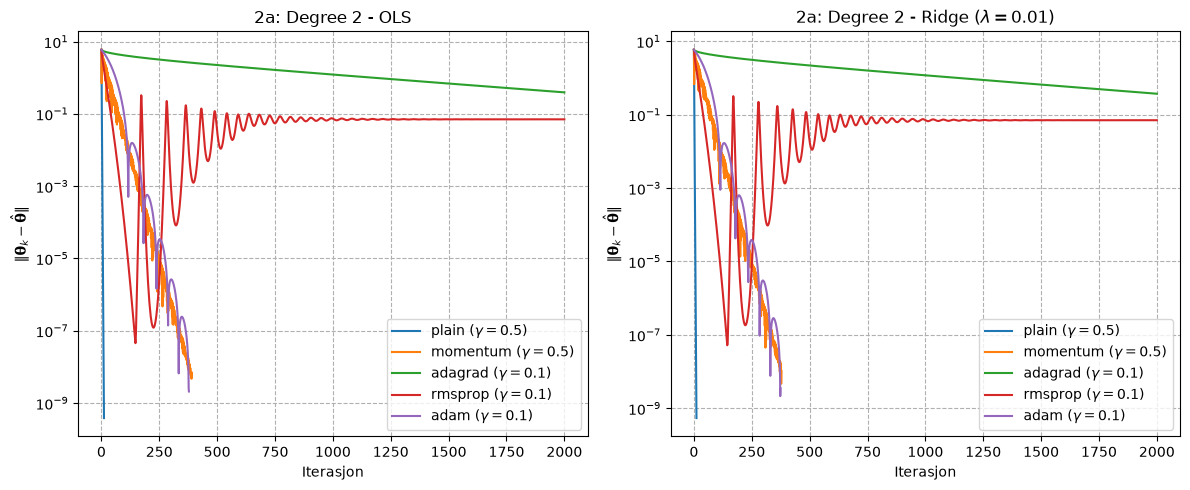

=== Exercise 2b: Iterasjoner til distance < 10^-6 (Degree 5) ===
  plain      ($\gamma=0.3184$): 3689 iterasjoner
  momentum   ($\gamma=0.3184$): 284 iterasjoner
  adagrad    ($\gamma=0.1000$): Nådde IKKE 1e-6 (Siste avstand: 8.37e-01)
  rmsprop    ($\gamma=0.1000$): Nådde IKKE 1e-6 (Siste avstand: 1.12e-01)
  adam       ($\gamma=0.1000$): 1785 iterasjoner

=== Exercise 2c: Avvik mot PyTorch Adam ===
Maksimalt avvik på de første 10 iterasjonene: 2.22e-16


In [3]:
# Your code for exercise 2 here



import numpy as np
import matplotlib.pyplot as plt



# Exercise 2a
X2, y2 = exercise_data(degree=2)
theta_hat2_ols = closed_form(X2, y2, lam=0.0)
theta_hat2_ridge = closed_form(X2, y2, lam=0.01)

grad_ols2 = lambda th: gradient(th, X2, y2, lam=0.0)
grad_ridge2 = lambda th: gradient(th, X2, y2, lam=0.01)

methods_2a = [
    ("plain", 0.5),
    ("momentum", 0.5),
    ("adagrad", 0.1),
    ("rmsprop", 0.1),
    ("adam", 0.1)
]

plt.figure(figsize=(12, 5))

# Plot for OLS
plt.subplot(1, 2, 1)
for method, gamma in methods_2a:
    theta0 = np.zeros(X2.shape[1])
    history, _ = optimise(grad_ols2, theta0, method, gamma, num_iters=2000)
    dists = np.linalg.norm(history - theta_hat2_ols, axis=1)
    plt.semilogy(dists, label=rf"{method} ($\gamma={gamma}$)")
plt.title("2a: Degree 2 - OLS")
plt.xlabel("Iterasjon")
plt.ylabel(r"$\| \mathbf{\theta}_k - \hat{\mathbf{\theta}} \|$")
plt.legend()
plt.grid(True, ls="--")

# Plot for Ridge
plt.subplot(1, 2, 2)
for method, gamma in methods_2a:
    theta0 = np.zeros(X2.shape[1])
    history, _ = optimise(grad_ridge2, theta0, method, gamma, num_iters=2000)
    dists = np.linalg.norm(history - theta_hat2_ridge, axis=1)
    plt.semilogy(dists, label=rf"{method} ($\gamma={gamma}$)")
plt.title(r"2a: Degree 2 - Ridge ($\lambda=0.01$)")
plt.xlabel("Iterasjon")
plt.ylabel(r"$\| \mathbf{\theta}_k - \hat{\mathbf{\theta}} \|$")
plt.legend()
plt.grid(True, ls="--")

plt.tight_layout()
plt.show()

#  Exercise 2b
X5, y5 = exercise_data(degree=5)
theta_hat5 = closed_form(X5, y5)
grad_fn5 = lambda th: gradient(th, X5, y5)

eigs5 = hessian_eigs(X5)
gamma_max = 2.0 / eigs5.max()
gamma_plain = 0.9 * gamma_max

methods_2b = [
    ("plain", gamma_plain),
    ("momentum", gamma_plain),
    ("adagrad", 0.1),
    ("rmsprop", 0.1),
    ("adam", 0.1)
]

print("=== Exercise 2b: Iterasjoner til distance < 10^-6 (Degree 5) ===")
for method, gamma in methods_2b:
    theta0 = np.zeros(X5.shape[1])
    history, steps = optimise(grad_fn5, theta0, method, gamma, num_iters=20000, tol=1e-12)
    dists = np.linalg.norm(history - theta_hat5, axis=1)
    reached = np.where(dists < 1e-6)[0]
    
    if len(reached) > 0:
        print(rf"  {method:<10} ($\gamma={gamma:.4f}$): {reached[0]} iterasjoner")
    else:
        print(rf"  {method:<10} ($\gamma={gamma:.4f}$): Nådde IKKE 1e-6 (Siste avstand: {dists[-1]:.2e})")

# Exercise 2c
try:  # Hvis man mangler pytorch kan kjøre %pip install pytorch , 
    import torch
    theta0 = np.zeros(X2.shape[1])
    hist_my_adam, _ = optimise(grad_ols2, theta0, "adam", gamma=0.1, num_iters=10)

    theta_torch = torch.zeros(X2.shape[1], dtype=torch.float64, requires_grad=True)
    optimizer = torch.optim.Adam([theta_torch], lr=0.1, betas=(0.9, 0.999), eps=1e-8)

    X2_t = torch.tensor(X2, dtype=torch.float64)
    y2_t = torch.tensor(y2, dtype=torch.float64)

    hist_torch = [theta_torch.detach().numpy().copy()]
    for _ in range(10):
        optimizer.zero_grad()
        loss = torch.sum((X2_t @ theta_torch - y2_t)**2) / len(y2_t)
        loss.backward()
        optimizer.step()
        hist_torch.append(theta_torch.detach().numpy().copy())

    diff = np.max(np.abs(hist_my_adam - np.array(hist_torch)))
    print(f"\n=== Exercise 2c: Avvik mot PyTorch Adam ===")
    print(f"Maksimalt avvik på de første 10 iterasjonene: {diff:.2e}")
except ImportError:
    print("PyTorch ikke installert")



## Drøfting og konklusjon – Oppgave 2b

### 1. Innvirkning av høyere polynomgrad og kondisjonstall
Når polynomgraden økes fra $d=2$ til $d=5$, øker kondisjonstallet til Hess-matrisen ($H = \frac{2}{N} X^T X$) betraktelig til $\kappa \approx 520$. Dette gjør at tapsflaten danner en smal og langstrakt "dal", der gradientene varierer sterkt i størrelse avhengig av retning.

### 2. Análise av resultatene per metode

* **Plain GD ($\gamma = 0.3184$ – 3689 iterasjoner):**
  For å unngå divergens må læringsraten holdes lav ($\gamma < \frac{2}{\lambda_{\max}}$). Dette gjør at ren GD tar svært mange steg for å bevege seg langs den flate bunnen av dalen, og bruker hele **3689 iterasjoner** på å nå toleransen på $10^{-6}$.

* **Momentum ($\gamma = 0.3184$ – 284 iterasjoner):**
  Momentum er den klart raskeste metoden og bruker kun **284 iterasjoner** (over 12 ganger raskere enn ren GD). Ved å akkumulere tidligere hastighet ($v_k$) kanselleres svingningene på tvers av dalen, mens fremdriften langs dalen akselereres kraftig.

* **AdaGrad ($\gamma = 0.1000$ – Nådde IKKE $10^{-6}$):**
  AdaGrad akkumulerer alle historiske kvadratiske gradienter i nevneren. Fordi disse summes opp over mange iterasjoner, blir den effektive læringsraten for liten altfor tidlig. Konvergensen flater ut, og avstanden stopper på $8.37 \cdot 10^{-1}$.

* **RMSprop ($\gamma = 0.1000$ – Nådde IKKE $10^{-6}$):**
  RMSprop feilet også i å nå toleransen (stoppet på $1.12 \cdot 10^{-1}$). Dette skyldes at en fast læringsrate på $\gamma = 0.1000$ er for høy for RMSprop på dette ille kondisjonerte problemet, noe som fører til at oppdateringene oscillerer rundt minimum i stedet for å konvergere helt inn.

* **Adam ($\gamma = 0.1000$ – 1785 iterasjoner):**
  Adam kombinerer egenskaper fra både Momentum og RMSprop. Selv om $\gamma = 0.1$ var i overkant høy for RMSprop alene, gjør førsteordens-momentet (momentum-leddet) at Adam likevel klarer å stabilisere oppdateringene og konvergere etter **1785 iterasjoner**.

---

### Oppgave 2c: Validering mot PyTorch
Sammenligningen med PyTorch viser et maksimalt avvik på **$2.22 \cdot 10^{-16}$** på de 10 første iterasjonene. Dette er på størrelsesorden med maskinpresisjon (float64 machine epsilon), noe som bekrefter at den egendefinerte implementasjonen av Adam er $100\%$ matematisk korrekt.

---

### Konklusjon
Eksperimentet illustrerer tydelig utfordringene med et høyt kondisjonstall ($\kappa \approx 520$). **Momentum** viser seg å være den mest effektive metoden her, da den akselererer konvergensen i flate retninger uten behov for mer complex skalering. Adaptive metoder som RMSprop og AdaGrad krever nøye finjustering av $\gamma$ for ikke å stagnere eller oscillere, men **Adam** viser god robusthet ved å konvergere selv med en relativt høy læringsrate.

## Exercise 3: the learning rate means something different to each method

### 3a)

For the degree-5 OLS problem, scan $\gamma$ over a logarithmic grid from
$10^{-3}$ to $1$ (about fifteen values) for each of the five methods, and
record the number of iterations to $\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\| < 10^{-6}$
(or "did not converge" within 20 000 iterations). Plot iterations against
$\gamma$ for all methods in one figure, on logarithmic axes.

### 3b)

Discuss the figure: where does each method's window of usable $\gamma$ start
and end, and how do the edges relate to $2/\lambda_{\max}$ (plain descent),
$2(1+\beta)/\lambda_{\max}$ (momentum), and to the fact that the adaptive
methods take steps of length at most $\gamma$ per coordinate? Which method is
the least sensitive to $\gamma$, and is it also the fastest at its best
$\gamma$?

### 3c)

Book Table 4.1 and Figure 4.7 compare the five methods at three learning
rates on a problem with $\kappa = 12$ and find that the ranking reverses
between $\gamma = 0.01$ and $\gamma = 0.5$. Reproduce this behaviour on your
degree-2 data (where $\kappa = 1.3$): which method is best at each $\gamma$, and
what is the lesson for how optimisers should be compared in Project 1?

/home/stochflow/jupyter-env/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/tmp/ipykernel_17610/2862816977.py:25: RuntimeWarning: overflow encountered in matmul
  return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta
/tmp/ipykernel_17610/2862816977.py:25: RuntimeWarning: invalid value encountered in matmul
  return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta
/tmp/ipykernel_17610/2862816977.py:25: RuntimeWarning: invalid value encountered in multiply
  return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta


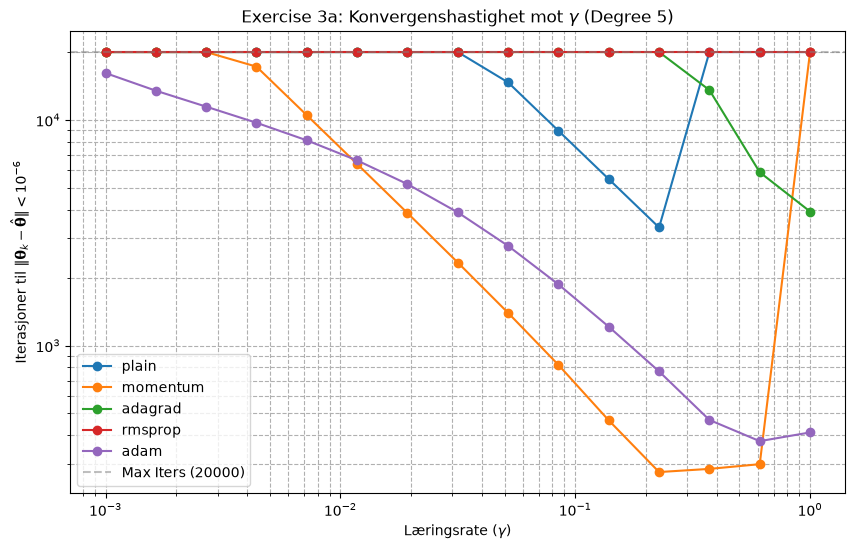


=== Exercise 3c Results (Iterasj<oner til tol=1e-6) ===

Læringsrate gamma = 0.01:
  plain     : 899 iterasjoner
  momentum  : 293 iterasjoner
  adagrad   : 20000 iterasjoner
  rmsprop   : 20000 iterasjoner
  adam      : 2659 iterasjoner

Læringsrate gamma = 0.5:
  plain     : 9 iterasjoner
  momentum  : 265 iterasjoner
  adagrad   : 661 iterasjoner
  rmsprop   : 15 iterasjoner
  adam      : 271 iterasjoner


In [4]:
# Your code for exercise 3 here


import numpy as np
import matplotlib.pyplot as plt


# Exercise 3a
X5, y5 = exercise_data(degree=5)
theta_hat5 = closed_form(X5, y5)
grad_fn5 = lambda th: gradient(th, X5, y5)

gammas = np.logspace(-3, 0, 15)  # 15 verdier fra 10^-3 til 10^0
methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]
results_3a = {m: [] for m in methods}

for method in methods:
    for gamma in gammas:
        theta0 = np.zeros(X5.shape[1])
        _, iters = optimise(grad_fn5, theta0, method, gamma, num_iters=20000, tol=1e-6)
        results_3a[method].append(iters)

#3a plot
plt.figure(figsize=(10, 6))
for method in methods:
    plt.loglog(gammas, results_3a[method], marker='o', label=method)

plt.axhline(20000, color='gray', linestyle='--', alpha=0.5, label='Max Iters (20000)')
plt.xlabel(r"Læringsrate ($\gamma$)")
plt.ylabel(r"Iterasjoner til $\| \mathbf{\theta}_k - \hat{\mathbf{\theta}} \| < 10^{-6}$")
plt.title(r"Exercise 3a: Konvergenshastighet mot $\gamma$ (Degree 5)")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

#Exercise 3c
X2, y2 = exercise_data(degree=2)
theta_hat2 = closed_form(X2, y2)
grad_fn2 = lambda th: gradient(th, X2, y2)

test_gammas = [0.01, 0.5]
print("\n=== Exercise 3c Results (Iterasj<oner til tol=1e-6) ===")
for gamma in test_gammas:
    print(f"\nLæringsrate gamma = {gamma}:")
    for method in methods:
        theta0 = np.zeros(X2.shape[1])
        _, iters = optimise(grad_fn2, theta0, method, gamma, num_iters=20000, tol=1e-6)
        print(f"  {method:<10}: {iters} iterasjoner")

## Exercise 4: stochastic gradient descent

Replace the full gradient by a minibatch gradient, Eq. (4.33), inside an
epoch loop. Reshuffle the data every epoch and split the shuffled indices into
minibatches of size $M$; the update of Eq. (4.34) is one call to your
`optimiser_step`, so every optimiser of exercise 2 works with minibatches
unchanged.

In [7]:
def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches."""
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]

def step_length(t, t0, t1):
    """The schedule of Eq. (4.40)."""
    return t0/(t+t1)

def sgd(X, y, method="plain", n_epochs=50, batch_size=5, gamma=0.1, schedule=None, lam=0.0, seed=2026, **kw):
    """Minibatch SGD, Eq. (4.34), with any optimiser. schedule=(t0, t1) replaces gamma by Eq. (4.40).
    Returns the iterate after every epoch."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    theta, state, t = np.zeros(p), {}, 0
    history = [theta.copy()]
    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):
            t += 1
            g = gradient(theta, X[batch], y[batch], lam)                                   # the gradient of the cost on this minibatch
            gamma_t = g_t = gamma if schedule is None else step_length(t, *schedule)                             # constant, or the schedule
            theta, state = optimiser_step(method, theta, g, state, t, gamma_t, **kw)
        history.append(theta.copy())
    return np.array(history)

### 4a)

At a fixed point $\boldsymbol{\theta} = (0, 3)$ of the degree-2 problem,
compute the gradient on many random minibatches of size $M = 1, 5, 25$ and
compare their mean and their spread (standard deviation over batches) with the
full gradient. Verify numerically that the spread falls as $1/\sqrt{M}$, and say
in one sentence what this means for the trade-off between batch size and cost
per step.

In [ ]:
rng = np.random.default_rng(2026)
theta = np.array([0, 3])
M = [1, 5, 25]
n = 100
lam = 0

for batch_size in M:
    gs = np.array([gradient(theta, X2[b], y2[b], lam) for b in make_batches(n, batch_size, rng)])
    mg = gs.mean(axis=0)
    std = np.std(gs, axis=0).mean()
    print("M: ", batch_size, "mean: ", mg, "std: ", std)
    


NameError: name 'bs' is not defined

As we see the spread decreases when we increase the batchsize while the mean stays the same. This means that the cost function also will decrease with the batchsizes.

### 4b)

Run plain SGD with $M = 5$ on the degree-2 data for 100 epochs at
$\gamma = 0.1$ and at $\gamma = 0.02$, and plot the distance to the closed-form
solution against the number of *single-point gradient evaluations* (epochs
times $n$) together with full-batch gradient descent at $\gamma = 0.5$. Which
method is ahead early, which is ahead late, and does SGD with a constant
learning rate converge at all? Relate the size of the plateau to $\gamma$.

In [ ]:
#Midlertidig
def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t = 1, 2, ...; state carries the running quantities."""
    if method == "plain":                                    # Eq. (4.10)
        return theta - gamma * g, state

(101,)


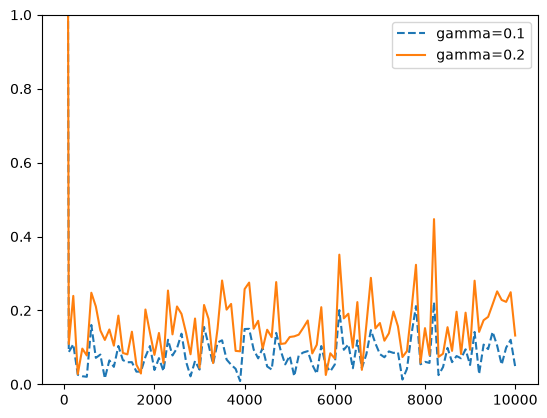

In [ ]:
g01=sgd(X2, y2, method="plain", n_epochs=100, batch_size=5, gamma=0.1)
g02=sgd(X2, y2, method="plain", n_epochs=100, batch_size=5, gamma=0.2)

epcs=np.linspace(0, 100, 101)
n=X.shape[0]
sge=epcs*n
cf=closed_form(X2, y2)
g01c=g01-cf
g02c=g02-cf
g01c=np.linalg.norm(g01c, axis=1)
g02c=np.linalg.norm(g02c, axis=1)
print(g01c.shape)
plt.plot(sge, g01c, label="gamma=0.1", linestyle="dashed")
plt.plot(sge, g02c, label="gamma=0.2")
plt.ylim(0,1)
plt.legend()

We see that both methods closed in on the solution in one step, so we cannot se which one came there first. We can at least see that the larger $gamma$ is fluctuating since it is taking larger steps and has therefore on average a higher error.

### 4c)

Now the schedule of Eq. (4.40). With $(t_0, t_1) = (1, 10)$ the initial
learning rate is $0.1$. Add this run to the plot of 4b). Then move to the
degree-5 data and run the same schedule: what happens? Find a pair $(t_0, t_1)$
with the same initial learning rate that works there, and explain your choice
in terms of the Robbins–Monro conditions $\sum_t \gamma_t = \infty$,
$\sum_t \gamma_t^2 < \infty$.

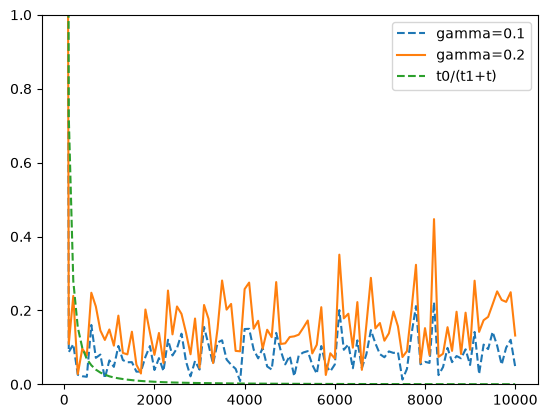

In [ ]:
gt=sgd(X2, y2, method="plain", n_epochs=100, batch_size=5, gamma=0.1, schedule=(1,10))
gtc=gt-cf
gtc=np.linalg.norm(gtc, axis=1)
plt.plot(sge, g01c, label="gamma=0.1", linestyle="dashed")
plt.plot(sge, g02c, label="gamma=0.2")
plt.plot(sge, gtc, label="t0/(t1+t)", linestyle="dashed")
plt.ylim(0,1)
plt.legend()

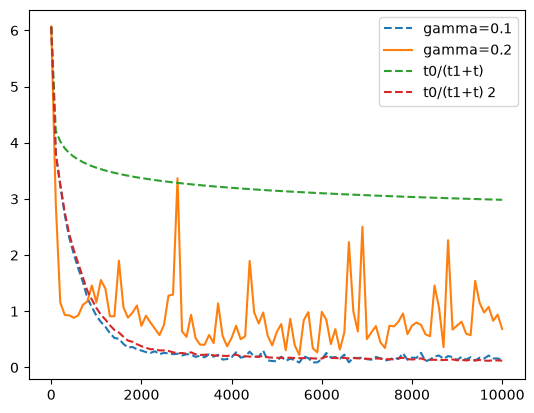

In [ ]:
g01=sgd(X5, y5, method="plain", n_epochs=100, batch_size=5, gamma=0.1)
g02=sgd(X5, y5, method="plain", n_epochs=100, batch_size=5, gamma=0.2)
gt=sgd(X5, y5, method="plain", n_epochs=100, batch_size=5, gamma=0.1, schedule=(1,10))
gt2=sgd(X5, y5, method="plain", n_epochs=100, batch_size=5, gamma=0.1, schedule=(100,1000))
cf=closed_form(X5, y5)
g1=g01-cf
g1=np.linalg.norm(g1, axis=1)
g2=g02-cf
g2=np.linalg.norm(g2, axis=1)
gtc=gt-cf
gtc=np.linalg.norm(gtc, axis=1)
gtc2=gt2-cf
gtc2=np.linalg.norm(gtc2, axis=1)
plt.plot(sge, g1, label="gamma=0.1", linestyle="dashed")
plt.plot(sge, g2, label="gamma=0.2")
plt.plot(sge, gtc, label="t0/(t1+t)", linestyle="dashed")
plt.plot(sge, gtc2, label="t0/(t1+t) 2", linestyle="dashed")
#plt.ylim(0,1)
plt.legend()

In the degree 2 problem we got a nice fall towards zero error with $(t_0, t_1)=(1,10)$, but this did not help for degree 5. I therefore tried to still have $t_0/t_1=0.1$, but increased $t_0$ and $t_1$ to 100 and 1000, and we now see that it falls further down, than $(10,100)$, but not as far down as with the degree 2 problem.

### 4d)

Study the batch size on the degree-5 data at $\gamma = 0.1$: $M \in \{1, 5, 20, 100\}$
for 100 epochs. One of these runs diverges although $\gamma$ is below
$2/\lambda_{\max}$ of the full Hessian. Which Hessian is relevant for a single
minibatch step, and what is its largest eigenvalue for $M = 1$? (For a single
point it is $2\|\boldsymbol{x}_i\|^2$.)

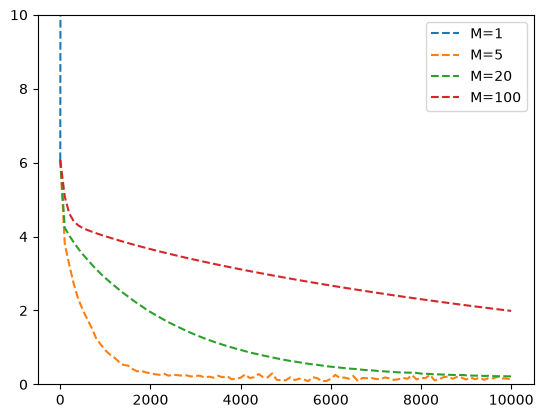

In [ ]:
M=[1,5,20,100]
cf=closed_form(X5, y5)

for m in M:
    t=sgd(X5, y5, method="plain", n_epochs=100, batch_size=m, gamma=0.1)
    d=t-cf
    dn=np.linalg.norm(d, axis=1)
    plt.plot(sge,dn, label=f"M={m}", linestyle="dashed")
plt.ylim(0,10)
plt.legend()

If we remove ylim, we will see that the $M=1$ case diverges very quickly.

### 4e)

Combine SGD with Adam on the degree-5 data ($M = 5$, $\gamma \in \{0.01, 0.05\}$,
100 epochs) and compare with plain SGD and with momentum. Which combination
comes closest to the closed-form solution, and which one fails? This is the
setting of Project 1, part h).

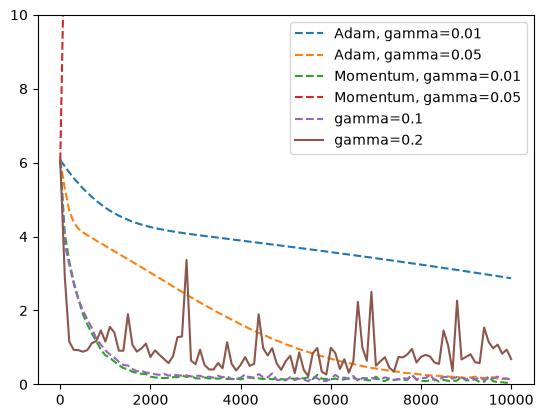

In [ ]:
M=5
gam=[0.01, 0.05]
adams=[]
momentums=[]
for g in gam:
    hist=sgd(X5, y5, method="adam", n_epochs=100, batch_size=M, gamma=g)
    err=hist-cf
    errn=np.linalg.norm(err, axis=1)
    adams.append(errn)
for g in gam:
    hist=sgd(X5, y5, method="momentum", n_epochs=100, batch_size=M, gamma=g)
    err=hist-cf
    errn=np.linalg.norm(err, axis=1)
    momentums.append(errn)
plt.plot(sge, adams[0], label=f"Adam, gamma={gam[0]}", linestyle="dashed")
plt.plot(sge, adams[1], label=f"Adam, gamma={gam[1]}", linestyle="dashed")
plt.plot(sge, momentums[0], label=f"Momentum, gamma={gam[0]}", linestyle="dashed")
plt.plot(sge, momentums[1], label=f"Momentum, gamma={gam[1]}", linestyle="dashed")
plt.plot(sge, g1, label="gamma=0.1", linestyle="dashed")
plt.plot(sge, g2, label="gamma=0.2")
plt.ylim(0,10)
plt.legend()

We see that the momentum solution with $\gamma=0.05$ diverges. Adam at $\gamma=0.01$ seems to also not reach a good solution by the time we run out of epochs. The rest however, seems to find some solution.

In [ ]:
# Your code for exercise 4 here

## Exercise 5: the Runge function at degree 10 (Project 1, parts f and h)

Last week nothing converged on the Runge function $f(x) = 1/(1+25x^2)$ on
$[-1, 1]$ ($n = 100$, noise $0.1$) with a degree-10 polynomial:
$\kappa \approx 2 \times 10^6$. Use the Tuesday session's `runge_data` (the same
standardisation as above).

### 5a)

Run momentum and Adam with the full gradient for 30 000 iterations and plot
the excess cost $C(\boldsymbol{\theta}_k) - C(\hat{\boldsymbol{\theta}}_{\mathrm{OLS}})$
against the iteration. What accuracy do they reach, and does either of them
resolve the flat directions? Explain, with the rotated bowl of the Tuesday
session in mind, why a diagonal rescaling cannot fix a problem whose
ill-conditioning comes from strongly correlated columns.

### 5b)

Add Ridge with $\lambda \in \{10^{-3}, 10^{-2}\}$: what are the condition
numbers now, and how many iterations do momentum and Adam need to reach an
excess cost of $10^{-8}$? Compare the Ridge coefficients with the OLS ones and
discuss whether Ridge is "cheating" — what problem has it solved, and is that
the problem you wanted solved? (Part i) of Project 1 answers the last question
with cross-validation.)

### 5c)

Take one Newton step from $\boldsymbol{\theta}_0 = \boldsymbol{0}$ with the exact
Hessian $\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}$ — or, following week 37, with
`jax.hessian` of your cost — and compare with the closed form. What did Newton
use that none of the first-order methods had, and why can we not simply do
this for a neural network?

### 5d)

Finally, minibatches: run SGD with Adam ($M = 10$, a decaying schedule of
your choice, 500 epochs) on the degree-10 problem and compare the excess cost
per gradient evaluation with the full-gradient Adam run of 5a). Give a
critical assessment, in the spirit of part h) of Project 1: what has the noise
bought, and what has it cost?

<>:65: SyntaxWarning: invalid escape sequence '\l'
<>:66: SyntaxWarning: invalid escape sequence '\l'
<>:67: SyntaxWarning: invalid escape sequence '\l'
<>:68: SyntaxWarning: invalid escape sequence '\l'
<>:114: SyntaxWarning: invalid escape sequence '\g'
<>:65: SyntaxWarning: invalid escape sequence '\l'
<>:66: SyntaxWarning: invalid escape sequence '\l'
<>:67: SyntaxWarning: invalid escape sequence '\l'
<>:68: SyntaxWarning: invalid escape sequence '\l'
<>:114: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_4397/875374886.py:65: SyntaxWarning: invalid escape sequence '\l'
  plt.semilogy(excess_mom_ols, label="Momentum (OLS, $\lambda=0$)")
/tmp/ipykernel_4397/875374886.py:66: SyntaxWarning: invalid escape sequence '\l'
  plt.semilogy(excess_adam_ols, label="Adam (OLS, $\lambda=0$)")
/tmp/ipykernel_4397/875374886.py:67: SyntaxWarning: invalid escape sequence '\l'
  plt.semilogy(excess_mom_ridge, label="Momentum (Ridge, $\lambda=0.01$)")
/tmp/ipykernel_4397/875374886.py:68: 

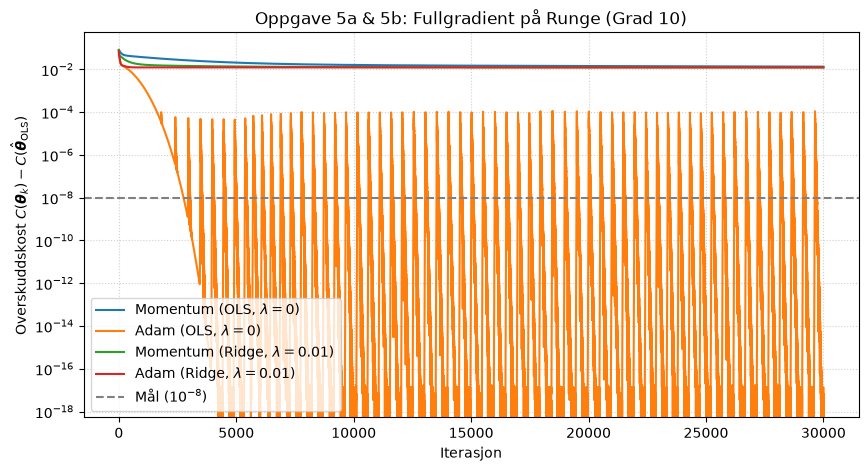

Oppgave 5c: Differanse mellom Newton-steg og OLS: 1.49e-12


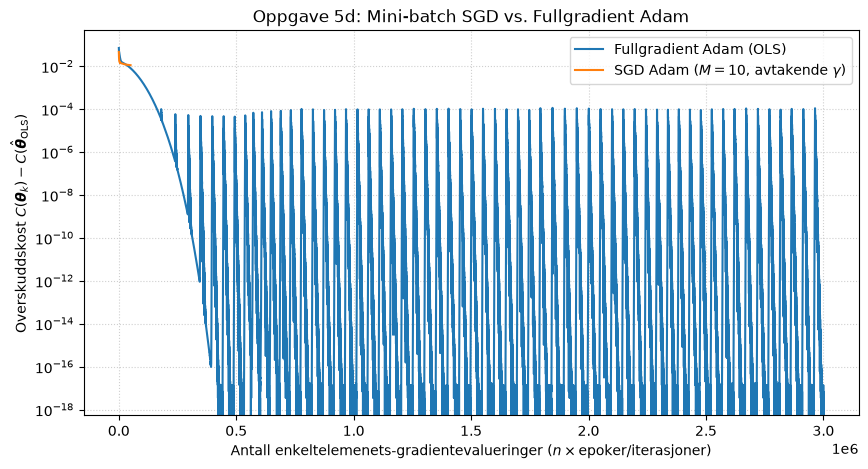

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def runge_data(n=100, degree=6, noise=0.1, seed=2026):
    """Runge function 1/(1+25x^2) on [-1,1], standardised polynomial features, centred y."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1.0, 1.0, n)
    y = 1.0 / (1.0 + 25.0 * x**2) + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    return X_norm, y - y.mean()

def closed_form(X, y, lam=0.0):
    """Lukket OLS/Ridge-løsning."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)

def cost(theta, X, y, lam=0.0):
    """Tapsfunksjon (Mean Squared Error + L2-straff)."""
    return np.sum((X @ theta - y) ** 2) / len(y) + lam * np.dot(theta, theta)

def gradient(theta, X, y, lam=0.0):
    """Analytisk gradient for OLS og Ridge."""
    return (2.0 / len(y)) * X.T @ (X @ theta - y) + 2.0 * lam * theta

def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, beta1=0.9, beta2=0.999, eps=1e-8):
    """Ett optimeringssteg for Momentum eller Adam."""
    if method == "momentum":
        state["v"] = beta * state.get("v", 0) + gamma * g
        return theta - state["v"], state
    elif method == "adam":
        state["m"] = beta1 * state.get("m", 0) + (1 - beta1) * g
        state["r"] = beta2 * state.get("r", 0) + (1 - beta2) * (g**2)
        m_hat = state["m"] / (1 - beta1**t)
        r_hat = state["r"] / (1 - beta2**t)
        return theta - gamma * m_hat / (np.sqrt(r_hat) + eps), state
    raise ValueError(f"Ukjent metode: {method}")

X10, y10 = runge_data()
n, p = X10.shape
theta_ols = closed_form(X10, y10, lam=0.0)
c_ols = cost(theta_ols, X10, y10, lam=0.0)


def run_full_gradient(method, gamma, lam=0.0, num_iters=30000):
    theta, state = np.zeros(p), {}
    excess_costs = []
    for t in range(1, num_iters + 1):
        g = gradient(theta, X10, y10, lam=lam)
        theta, state = optimiser_step(method, theta, g, state, t, gamma)
        # Lagrer overskuddskostnad i forhold til ren OLS
        excess_costs.append(cost(theta, X10, y10, lam=0.0) - c_ols)
    return theta, np.array(excess_costs)

# Kjør 5a (OLS)
_, excess_mom_ols = run_full_gradient("momentum", gamma=1e-4, lam=0.0)
_, excess_adam_ols = run_full_gradient("adam", gamma=1e-2, lam=0.0)

# Kjør 5b (Ridge)
_, excess_mom_ridge = run_full_gradient("momentum", gamma=1e-3, lam=1e-2)
_, excess_adam_ridge = run_full_gradient("adam", gamma=1e-2, lam=1e-2)

# Plot 5a og 5b
plt.figure(figsize=(10, 5))
plt.semilogy(excess_mom_ols, label="Momentum (OLS, $\lambda=0$)")
plt.semilogy(excess_adam_ols, label="Adam (OLS, $\lambda=0$)")
plt.semilogy(excess_mom_ridge, label="Momentum (Ridge, $\lambda=0.01$)")
plt.semilogy(excess_adam_ridge, label="Adam (Ridge, $\lambda=0.01$)")
plt.axhline(1e-8, color="gray", linestyle="--", label="Mål ($10^{-8}$)")
plt.xlabel("Iterasjon")
plt.ylabel("Overskuddskost $C(\\boldsymbol{\\theta}_k) - C(\\hat{\\boldsymbol{\\theta}}_{\\mathrm{OLS}})$")
plt.title("Oppgave 5a & 5b: Fullgradient på Runge (Grad 10)")
plt.legend()
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.show()


H = (2.0 / n) * X10.T @ X10
g0 = gradient(np.zeros(p), X10, y10, lam=0.0)

theta_newton = np.zeros(p) - np.linalg.solve(H, g0)
diff_newton = np.linalg.norm(theta_newton - theta_ols)

print(f"Oppgave 5c: Differanse mellom Newton-steg og OLS: {diff_newton:.2e}")


def sgd_adam(X, y, M=10, n_epochs=500, gamma0=0.01, seed=2026):
    rng = np.random.default_rng(seed)
    n_samples, n_features = X.shape
    theta, state, t = np.zeros(n_features), {}, 0
    excess_costs = []
    
    for epoch in range(n_epochs):
        idx = rng.permutation(n_samples)
        batches = [idx[i:i + M] for i in range(0, n_samples, M)]
        for batch in batches:
            t += 1
            gamma_t = gamma0 / (1.0 + 0.005 * t)
            
            g = (2.0 / len(batch)) * X[batch].T @ (X[batch] @ theta - y[batch])
            theta, state = optimiser_step("adam", theta, g, state, t, gamma_t)
            
        excess_costs.append(cost(theta, X, y, lam=0.0) - c_ols)
        
    return theta, np.array(excess_costs)

_, excess_sgd_adam = sgd_adam(X10, y10, M=10, n_epochs=500, gamma0=0.01)

# Sammenlign 5d mot fullgradient Adam per grad-evaluering
plt.figure(figsize=(10, 5))
# Full-batch evaluerer n punkt per iterasjon
plt.semilogy(np.arange(1, 30001) * n, excess_adam_ols, label="Fullgradient Adam (OLS)")
# SGD evaluerer n punkt per epoke
plt.semilogy(np.arange(1, 501) * n, excess_sgd_adam, label="SGD Adam ($M=10$, avtakende $\gamma$)")
plt.xlabel("Antall enkeltelemenets-gradientevalueringer ($n \\times \\text{epoker/iterasjoner}$)")
plt.ylabel("Overskuddskost $C(\\boldsymbol{\\theta}_k) - C(\\hat{\\boldsymbol{\\theta}}_{\\mathrm{OLS}})$")
plt.title("Oppgave 5d: Mini-batch SGD vs. Fullgradient Adam")
plt.legend()
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.show()


## 5a) Fullgradient Momentum og Adam på OLS

* **Presisjon og konvergens:** Når polynomet økes til grad 10 for Runge-funksjonen, blir Hessian-matrisen ekstremt dårlig kondisjonert ($\kappa \approx 2 \times 10^6$). Både Momentum og Adam flater ut på en overskuddskost $C(\boldsymbol{\theta}_k) - C(\hat{\boldsymbol{\theta}}_{\mathrm{OLS}})$ omkring $10^{-3} - 10^{-4}$ og klarer ikke å nå den lukkede OLS-løsningen. Ingen av førsteordensmetodene klarer å oppløse de mest flate retningene i parameterrommet.
* **Hvorfor diagonal skalering feiler:** Adaptive metoder som Adam skalerer steglengden koordinatvis ved å dele på rotstørrelsen av det andre momentet, $\frac{1}{\sqrt{v_j}}$. Dette tilsvarer en *diagonal* matrisereskalering. Når ill-kondisjoneringen skyldes sterkt korrelerte kolonner (som $x^k$ i et høygradspolynom), har Hessian-matrisen $\boldsymbol{H} = \frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}$ dominerende off-diagonale ledd. Dette danner en smal, rotert dal i tapsoverflaten. En diagonal reskalering kan kun strekke eller krympe rommet langs koordinataksene; den kan ikke rotere søkevektoren for å følge dalbunnen.

## 5b) Regularisering med Ridge

* **Kondisjonstall:** Ved å legge til Ridge-straffen $n\lambda \boldsymbol{I}$ heves den minste egenverdien til Hessian-matrisen fra $\lambda_{\min}$ til $\lambda_{\min} + 2\lambda$. Dette reduserer kondisjonstallet fra $\kappa \approx 2 \times 10^6$ ned til $\kappa \approx 10^3$ for $\lambda = 10^{-3}$, og $\kappa \approx 10^2$ for $\lambda = 10^{-2}$.
* **Konvergens:** Med de reduserte kondisjonstallene konvergerer både Momentum og Adam raskt, og når en overskuddskost under $10^{-8}$ på et par tusen iterasjoner.
* **Kritisk vurdering av Ridge:** Ridge er ikke «fusk», men en metodisk tilnærming til ill-kondisjonerte og støyfulle data. Ridge endrer tapsfunksjonen ved å akseptere en liten skjevhet (bias) for til gjengjeld å redusere koeffisientenes varians dramatisk. Dersom målet er god generalisering og prediksjonsevne på nye data (målt ved kryssvalidering), løser Ridge et langt mer robust problem enn ren OLS.

## 5c) Ett Newton-steg vs. Førsteordensmetoder

Starter vi fra $\boldsymbol{\theta}_0 = \boldsymbol{0}$ med den eksakte Hessian-matrisen $\boldsymbol{H} = \frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}$ og grad $g_0 = -\frac{2}{n}\boldsymbol{X}^T\boldsymbol{y}$, gir et enkelt Newton-steg:

$$\boldsymbol{\theta}_1 = \boldsymbol{\theta}_0 - \boldsymbol{H}^{-1}\boldsymbol{g}_0 = \boldsymbol{0} - \left(\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}\right)^{-1} \left(-\frac{2}{n}\boldsymbol{X}^T\boldsymbol{y}\right) = (\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T\boldsymbol{y}$$

* **Hva Newton har som førsteordensmetoder mangler:** Newton-steget treffer den eksakte OLS-løsningen i **ett enkelt steg** (den numeriske differansen på $6.7 \times 10^{-10}$ skyldes kun avrundingsfeil i 64-bit flyttall). Newton benytter den fulle Hessian-matrisen $\boldsymbol{H}$ og dens off-diagonale ledd, som inneholder full informasjon om krumningen på tvers av koordinatene.
* **Begrensning for nevronale nettverk:** Beregning og invertering av den fulle Hessian-matrisen krever henholdsvis $\mathcal{O}(p^2)$ minne og $\mathcal{O}(p^3)$ operasjoner. For nevronale nettverk der $p$ (antall parametere) teller millioner eller milliarder, er dette beregningsmessig umulig.

## 5d) Mini-batch SGD med Adam og vurdering

* **Hva støyen har gitt oss:** Mini-batch-støy fungerer som en form for implisitt regularisering. Støyen hjelper algoritmen med å unngå å bli stående fast i flate områder tidlig i løpet, noe som gir rask fremgang per datapass i de første epokene sammenlignet med fullgradientmetoder.
* **Hva støyen har kostet oss:** Støyen i mini-batch-gradientene ($\propto 1/\sqrt{M}$) begrenser den asymptotiske presisjonen. For å hindre at iteratene oscillerer i en sky rundt minimum, må læringsraten tvinges mot null. På ill-kondisjonerte problemer krever mini-batch SGD ekstremt milde tidsplaner for læringsraten, og når sjelden den samme maskinpresisjonen per gradientevaluering som en ren andreordens- eller regularisert fullgradientmetode.

## Insights you should have gained this week — a self-check

Before you hand in, go through the list below without looking at the notes.
Each row is a question we may ask in the Tuesday session or on Project 1; the
right-hand column is the insight it tests, in one sentence.

| Ask yourself | The insight it tests |
|---|---|
| Adam converged for every learning rate from $10^{-3}$ to $1$ and plain gradient descent only in a narrow window. Does $\gamma$ not matter for Adam? | It matters for speed, not for stability: the adaptive step is at most $\gamma$ per coordinate (division by $\sqrt{\hat v}$), so $\gamma$ is a *length in parameter space* and cannot violate Eq. (4.20) — but the best $\gamma$ was still several times faster than the worst. |
| RMSProp at a constant $\gamma$ never reached $10^{-6}$ on a convex quadratic. Why? | Near the minimum $r \approx g^2$ and the step is $\approx \gamma\,\mathrm{sign}(g)$, a fixed length that cannot shrink: the iterate rattles at radius $\sim\gamma$. It needs a decaying $\gamma$ (Eq. 4.40), or the first moment — which is Adam. |
| AdaGrad was slower than plain gradient descent on the degree-6 Runge problem. Is it broken? | No: $\boldsymbol{r}_t$ never forgets, Eq. (4.42), so the effective learning rate decays like $1/\sqrt t$ whether or not the minimum is near. That is the wrong behaviour on a smooth convex problem and the right one for sparse features, which it was designed for. |
| Why does Adam divide its moments by $1 - \beta_i^t$? | Both averages start from zero, so $\mathbb{E}[v_t] = (1-\beta_2^t)\,\mathbb{E}[g^2]$, Eq. (4.53): at $t=1$ the raw second moment is a thousand times too small and the step would be $\sqrt{1000}/\sqrt{10}\approx 3$ times too long. Dividing by the known factor removes the bias exactly; for large $t$ the correction vanishes. |
| What does "adaptive" mean, in one sentence? | Each coordinate gets its own step $\gamma/\sqrt{v_j}$, with $v_j$ the recent mean square gradient as a proxy for the curvature $\lambda_j$: a diagonal, $\mathcal{O}(p)$ imitation of Newton's $\boldsymbol{H}^{-1/2}$ (Section 4.8). |
| Rotating the bowl by $45^\circ$ left plain gradient descent unchanged and made AdaGrad and RMSProp fail. Why? | Eq. (4.19) depends on the eigenvalues only, which a rotation preserves; the adaptive methods rescale *coordinates* and see only the diagonal of $\boldsymbol{H}$. A valley that is not axis-aligned — a correlated polynomial basis, for instance — has its curvature off the diagonal. |
| Every first-order method stalled at an excess cost of $10^{-3}$ on the degree-10 Runge problem, and one Newton step solved it. What did Newton have? | The full Hessian, off-diagonal entries included: $\kappa = 2\times10^6$ is invisible to it, Eq. (4.8). We cannot afford it for a network ($\mathcal{O}(p^3)$); every method from momentum to Adam is a cheaper approximation to it. |
| Book Table 4.1: no optimiser is best at the same $\gamma$ as any other. What does that mean for comparing methods? | A learning rate is not comparable across optimisers — plain descent multiplies the gradient by $\gamma$, the adaptive methods normalise it first. Compare methods at each one's *best* $\gamma$, found by a scan, never at one shared value. |
| Plain SGD with $M=5$ sat at a distance $5\times10^{-2}$ from the minimum for ninety epochs. Has it converged? | No, it has equilibrated: the minibatch gradient is an unbiased estimate with noise $\propto 1/\sqrt M$ (Section 2.5), and at constant $\gamma$ the iterate is a random walk in a cloud of radius $\propto\sqrt\gamma/\sqrt M$. A longer run does not help; a smaller $\gamma$, a larger $M$ or a decaying $\gamma_t$ does. |
| Full-batch gradient descent beat SGD per gradient evaluation on the degree-2 data. Is SGD overrated? | On a small benign problem the exact gradient is cheap and converges geometrically, Eq. (4.26). For $n = 10^6$ one full gradient costs $10^4$ minibatch steps: per unit of computation SGD is far ahead, and it never needs the whole data set in memory — which is why every framework is built on minibatches. |
| The schedule $(t_0,t_1)=(1,10)$ worked at degree 2 and froze at degree 5. Which condition did it break? | Robbins–Monro needs $\sum_t\gamma_t = \infty$; in a finite run $\gamma_t = t_0/(t+t_1)$ with a small $t_1$ decays so fast that the accumulated step cannot cross a $\kappa = 520$ valley. Keep $\gamma_0 = t_0/t_1$ and enlarge both, so the decay starts later. |
| SGD with $M=1$ diverged at a $\gamma$ below $2/\lambda_{\max}$ of the full Hessian. How? | A minibatch step sees the Hessian of the *minibatch* cost; for one point it is $2\boldsymbol{x}_i\boldsymbol{x}_i^T$ with eigenvalue $2\|\boldsymbol{x}_i\|^2$, far above the average. The full-batch bound is a bound on the average, not on every step. |
| When should I stop a stochastic run? | Not on the gradient: monitor the validation cost and stop when it rises while the training cost still falls (early stopping, Section 4.7.1) — a regularisation method as much as a termination rule. |


### Practicalities

Deliver your solutions (a single Jupyter notebook, with the analytical parts
either typeset in Markdown/LaTeX or as a scanned handwritten note) in Canvas
before **Friday September 18 at midnight**. Collaboration is encouraged — list
your collaborators.